<a href="https://colab.research.google.com/github/Gigis09/Spring-2026-Speech-Emotion-recognition-project/blob/main/Pattern_Recognition_GRU.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import pickle
import torch
from glob import glob
from dataclasses import dataclass
from typing import List, Tuple, Dict

import numpy as np
import librosa
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, confusion_matrix, classification_report
SEED = 42

In [ ]:
@dataclass
class PreprocessConfig:
    # Audio
    sample_rate: int = 16000
    clip_seconds: float = 5.0
    mono: bool = True

    # STFT / Mel
    n_fft: int = 2048
    hop_length: int = 512
    n_mels: int = 128

    # MFCC
    n_mfcc: int = 13
    use_deltas: bool = False

    # Splits
    train_size: float = 0.70
    val_size_within_trainval: float = 0.15

In [ ]:
CACHE_DIR = "/home/ser_preprocessed"

def cache_exists():
    return os.path.exists(os.path.join(CACHE_DIR, "data.pkl"))

def save_cache(data):
    os.makedirs(CACHE_DIR, exist_ok=True)
    with open(os.path.join(CACHE_DIR, "data.pkl"), "wb") as f:
        pickle.dump(data, f)
    print("💾 Saved preprocessed data to cache")

def load_cache():
    with open(os.path.join(CACHE_DIR, "data.pkl"), "rb") as f:
        print("📂 Loaded preprocessed data from cache")
        return pickle.load(f)

In [ ]:
def get_predictions(model, loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)
            preds = outputs.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    return np.array(all_labels), np.array(all_preds)

In [ ]:
def build_label_map() -> Dict[str, str]:
    return {
        # CREMA / generic angry
        "ang": "angry", "a": "angry", "angry": "angry",
        # sad
        "sad": "sad", "sa": "sad",
        # happy
        "hap": "happy", "ha": "happy", "happy": "happy",
        # fear
        "fea": "fear", "f": "fear", "fear": "fear",
        # disgust
        "dis": "disgust", "d": "disgust", "disgust": "disgust",
        # neutral
        "neu": "neutral", "n": "neutral", "neutral": "neutral",
        # surprise
        "pleasant_surprise": "surprise", "surprise": "surprise",
        # RAVDESS numeric codes
        "01": "neutral",
        "02": "neutral",   # merge calm into neutral
        "03": "happy",
        "04": "sad",
        "05": "angry",
        "06": "fear",
        "07": "disgust",
        "08": "surprise",
    }

def list_audio_items(base_path: str, datasets: List[str], label_map: Dict[str, str]) -> List[Tuple[str, str]]:
    """
    Returns list of (filepath, normalized_label).
    Only includes Crema and Ravdess, as per your proposal.
    """
    items: List[Tuple[str, str]] = []

    for dataset in datasets:
        dataset_path = os.path.join(base_path, dataset)
        if not os.path.isdir(dataset_path):
            print(f"⚠️ Skipping missing folder: {dataset}")
            continue

        audio_files = sorted(glob(os.path.join(dataset_path, "**", "*.wav"), recursive=True))
        print(f"{dataset}: {len(audio_files)} files")

        for audio_file in audio_files:
            filename = os.path.basename(audio_file)

            if dataset == "Crema":
                parts = filename.split("_")
                if len(parts) < 3:
                    continue
                raw_label = parts[2]

            elif dataset == "Ravdess":
                parts = filename.split("-")
                if len(parts) < 3:
                    continue
                raw_label = parts[2]

            else:
                continue  # only Crema and Ravdess

            label = label_map.get(raw_label.lower(), raw_label.lower())
            items.append((audio_file, label))

    print(f"Collected {len(items)} labeled audio files.")
    return items

def load_and_fix_audio(path: str, cfg: PreprocessConfig) -> np.ndarray:
    y, sr = librosa.load(path, sr=cfg.sample_rate, mono=cfg.mono)
    target_len = int(cfg.clip_seconds * cfg.sample_rate)
    y = librosa.util.fix_length(y, size=target_len)
    peak = np.max(np.abs(y)) + 1e-9
    y = y / peak
    return y

def extract_mel_db(y: np.ndarray, cfg: PreprocessConfig) -> np.ndarray:
    mel = librosa.feature.melspectrogram(
        y=y,
        sr=cfg.sample_rate,
        n_fft=cfg.n_fft,
        hop_length=cfg.hop_length,
        n_mels=cfg.n_mels,
        power=2.0,
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)
    return mel_db

def extract_mfcc_seq(y: np.ndarray, cfg: PreprocessConfig) -> np.ndarray:
    mfcc = librosa.feature.mfcc(
        y=y,
        sr=cfg.sample_rate,
        n_fft=cfg.n_fft,
        hop_length=cfg.hop_length,
        n_mfcc=cfg.n_mfcc,
    )
    mfcc = mfcc.T

    if cfg.use_deltas:
        mfcc_t = mfcc.T
        d1 = librosa.feature.delta(mfcc_t).T
        d2 = librosa.feature.delta(mfcc_t, order=2).T
        mfcc = np.concatenate([mfcc, d1, d2], axis=1)

    return mfcc

def stratified_split_items(
    items: List[Tuple[str, str]],
    cfg: PreprocessConfig
) -> Tuple[List[Tuple[str, str]], List[Tuple[str, str]], List[Tuple[str, str]]]:
    paths = [p for p, _ in items]
    labels = [l for _, l in items]

    p_trainval, p_test, y_trainval, y_test = train_test_split(
        paths, labels,
        train_size=cfg.train_size,
        stratify=labels,
        random_state=SEED,
    )

    p_train, p_val, y_train, y_val = train_test_split(
        p_trainval, y_trainval,
        test_size=cfg.val_size_within_trainval,
        stratify=y_trainval,
        random_state=SEED,
    )

    train_items = list(zip(p_train, y_train))
    val_items = list(zip(p_val, y_val))
    test_items = list(zip(p_test, y_test))
    return train_items, val_items, test_items

def compute_normalization_stats_mfcc(X_mfcc: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    mean = X_mfcc.reshape(-1, X_mfcc.shape[-1]).mean(axis=0)
    std = X_mfcc.reshape(-1, X_mfcc.shape[-1]).std(axis=0) + 1e-9
    return mean, std

def apply_norm_mfcc(X_mfcc: np.ndarray, mean: np.ndarray, std: np.ndarray) -> np.ndarray:
    return (X_mfcc - mean[None, None, :]) / std[None, None, :]

def compute_normalization_stats_mel(X_mel: np.ndarray) -> Tuple[float, float]:
    mean = float(X_mel.mean())
    std = float(X_mel.std() + 1e-9)
    return mean, std

def apply_norm_mel(X_mel: np.ndarray, mean: float, std: float) -> np.ndarray:
    return (X_mel - mean) / std

def featurize_split(split_items: List[Tuple[str, str]], cfg: PreprocessConfig) -> Tuple[np.ndarray, np.ndarray, List[str]]:
    X_mfcc_list = []
    X_mel_list = []
    y_list = []

    for path, label in split_items:
        y = load_and_fix_audio(path, cfg)
        mfcc = extract_mfcc_seq(y, cfg)
        mel = extract_mel_db(y, cfg)

        X_mfcc_list.append(mfcc)
        X_mel_list.append(mel)
        y_list.append(label)

    X_mfcc = np.stack(X_mfcc_list, axis=0)
    X_mel = np.stack(X_mel_list, axis=0)    # Add channel dim later for CNN
    return X_mfcc, X_mel, y_list

def load_and_preprocess(cfg: PreprocessConfig):
    if cache_exists():
        return load_cache()

    base_path = kagglehub.dataset_download("dmitrybabko/speech-emotion-recognition-en")
    datasets = ["Crema", "Ravdess"]
    label_map = build_label_map()

    items = list_audio_items(base_path, datasets, label_map)

    train_items, val_items, test_items = stratified_split_items(items, cfg)

    X_mfcc_train, X_mel_train, y_train = featurize_split(train_items, cfg)
    X_mfcc_val, X_mel_val, y_val = featurize_split(val_items, cfg)
    X_mfcc_test, X_mel_test, y_test = featurize_split(test_items, cfg)

    le = LabelEncoder()
    y_train_enc = le.fit_transform(y_train)
    y_val_enc = le.transform(y_val)
    y_test_enc = le.transform(y_test)

    mfcc_mean, mfcc_std = compute_normalization_stats_mfcc(X_mfcc_train)
    X_mfcc_train = apply_norm_mfcc(X_mfcc_train, mfcc_mean, mfcc_std)
    X_mfcc_val = apply_norm_mfcc(X_mfcc_val, mfcc_mean, mfcc_std)
    X_mfcc_test = apply_norm_mfcc(X_mfcc_test, mfcc_mean, mfcc_std)

    mel_mean, mel_std = compute_normalization_stats_mel(X_mel_train)
    X_mel_train = apply_norm_mel(X_mel_train, mel_mean, mel_std)
    X_mel_val = apply_norm_mel(X_mel_val, mel_mean, mel_std)
    X_mel_test = apply_norm_mel(X_mel_test, mel_mean, mel_std)

    data = {
        "X_mfcc_train": X_mfcc_train,
        "X_mfcc_val": X_mfcc_val,
        "X_mfcc_test": X_mfcc_test,
        "X_mel_train": X_mel_train,
        "X_mel_val": X_mel_val,
        "X_mel_test": X_mel_test,
        "y_train": y_train_enc,
        "y_val": y_val_enc,
        "y_test": y_test_enc,
        "label_encoder": le,
        "cfg": cfg,
    }

    save_cache(data)
    return data

In [ ]:
    cfg = PreprocessConfig(
        sample_rate=22050,
        clip_seconds=5.0,
        n_fft=2048,
        hop_length=512,
        n_mels=128,
        n_mfcc=13,
        use_deltas=False,
    )
    data = load_and_preprocess(cfg)

100%|██████████| 987M/987M [00:09<00:00, 105MB/s]

Extracting files...


Crema: 7442 files
Ravdess: 1440 files
Collected 8882 labeled audio files.
💾 Saved preprocessed data to cache


In [ ]:
import torch
from torch.utils.data import TensorDataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_train = torch.tensor(data["X_mfcc_train"], dtype=torch.float32)
y_train = torch.tensor(data["y_train"], dtype=torch.long)

X_val = torch.tensor(data["X_mfcc_val"], dtype=torch.float32)
y_val = torch.tensor(data["y_val"], dtype=torch.long)

X_test = torch.tensor(data["X_mfcc_test"], dtype=torch.float32)
y_test = torch.tensor(data["y_test"], dtype=torch.long)

train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
import torch.nn as nn

class GRUClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout=0.3):
        super().__init__()
        self.gru = nn.GRU(
        input_size=input_size,
        hidden_size=hidden_size,
        num_layers=num_layers,
        batch_first=True,
        dropout=dropout if num_layers > 1 else 0.0,
        bidirectional=True
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x):
        out, _ = self.gru(x)
        out = torch.mean(out, dim=1)
        out = self.dropout(out)
        out = self.fc(out)
        return out

In [ ]:
input_size = X_train.shape[2]
num_classes = len(data["label_encoder"].classes_)

model = GRUClassifier(
    input_size=input_size,
    hidden_size=128,
    num_layers=2,
    num_classes=num_classes,
    dropout=0.3
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            total_loss += loss.item() * X_batch.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)


    return total_loss / total, correct / total

In [ ]:
CHECKPOINT_DIR = "/home/ser_checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

BEST_MODEL_PATH = os.path.join(CHECKPOINT_DIR, "best_gru_model.pt")

best_val_acc = 0.0
best_epoch = 0

num_epochs = 40

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    total = 0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)
        total += X_batch.size(0)

    train_loss = running_loss / total
    val_loss, val_acc = evaluate(model, val_loader, criterion)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch + 1
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f"Saved new best model at epoch {best_epoch} with val acc {best_val_acc:.4f}")

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

print(f"\nBest model was from epoch {best_epoch} with val acc {best_val_acc:.4f}")

Saved new best model at epoch 1 with val acc 0.3655
Epoch 1/40 | Train Loss: 1.6170 | Val Loss: 1.5389 | Val Acc: 0.3655
Saved new best model at epoch 2 with val acc 0.4212
Epoch 2/40 | Train Loss: 1.4524 | Val Loss: 1.4132 | Val Acc: 0.4212
Saved new best model at epoch 3 with val acc 0.4759
Epoch 3/40 | Train Loss: 1.3459 | Val Loss: 1.3170 | Val Acc: 0.4759
Saved new best model at epoch 4 with val acc 0.4909
Epoch 4/40 | Train Loss: 1.2681 | Val Loss: 1.2866 | Val Acc: 0.4909
Saved new best model at epoch 5 with val acc 0.5327
Epoch 5/40 | Train Loss: 1.1907 | Val Loss: 1.2596 | Val Acc: 0.5327
Saved new best model at epoch 6 with val acc 0.5391
Epoch 6/40 | Train Loss: 1.1033 | Val Loss: 1.1746 | Val Acc: 0.5391
Saved new best model at epoch 7 with val acc 0.5595
Epoch 7/40 | Train Loss: 1.0275 | Val Loss: 1.1203 | Val Acc: 0.5595
Saved new best model at epoch 8 with val acc 0.5756
Epoch 8/40 | Train Loss: 0.9459 | Val Loss: 1.1151 | Val Acc: 0.5756
Saved new best model at epoch 9 

Loaded best model checkpoint for final evaluation.
Test Loss: 1.1477 | Test Acc: 0.5970
Test F1 (macro): 0.5993
Test F1 (weighted): 0.5961
              precision    recall  f1-score   support

       angry     0.7068    0.7358    0.7210       439
     disgust     0.5701    0.5558    0.5629       439
        fear     0.4957    0.5216    0.5083       439
       happy     0.5990    0.5444    0.5704       439
     neutral     0.6615    0.7209    0.6899       412
         sad     0.5286    0.5262    0.5274       439
    surprise     0.8485    0.4828    0.6154        58

    accuracy                         0.5970      2665
   macro avg     0.6300    0.5839    0.5993      2665
weighted avg     0.5985    0.5970    0.5961      2665

Confusion Matrix:
[[323  51  20  25  11   8   1]
 [ 38 244  44  30  27  55   1]
 [ 23  35 229  55  26  71   0]
 [ 66  28  57 239  29  18   2]
 [  5  14  11  36 297  48   1]
 [  2  51  82  14  59 231   0]
 [  0   5  19   0   0   6  28]]


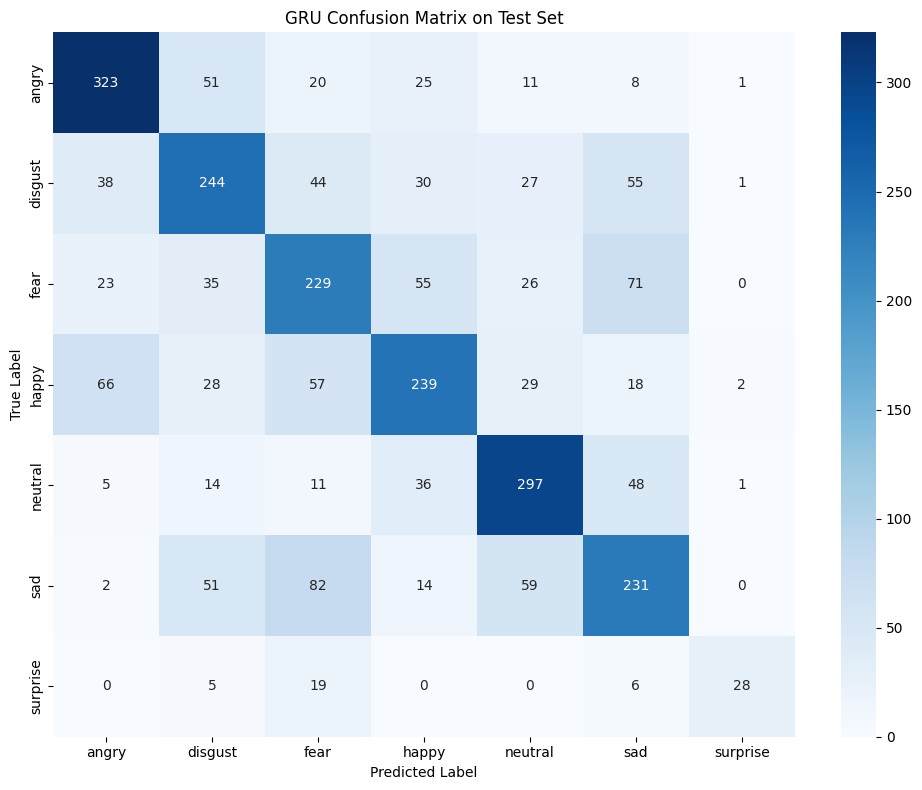

Saved confusion matrix to /home/ser_checkpoints/gru_confusion_matrix.png


In [ ]:
 model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
print("Loaded best model checkpoint for final evaluation.")

# Evaluate
test_loss, test_acc = evaluate(model, test_loader, criterion)
print(f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")

# Predictions
y_true, y_pred = get_predictions(model, test_loader)

# F1 scores
f1_macro = f1_score(y_true, y_pred, average="macro")
f1_weighted = f1_score(y_true, y_pred, average="weighted")
print(f"Test F1 (macro): {f1_macro:.4f}")
print(f"Test F1 (weighted): {f1_weighted:.4f}")

# Classification report
class_names = list(data["label_encoder"].classes_)
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("GRU Confusion Matrix on Test Set")
plt.tight_layout()

CONFUSION_MATRIX_PATH = os.path.join(CHECKPOINT_DIR, "gru_confusion_matrix.png")
plt.savefig(CONFUSION_MATRIX_PATH, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved confusion matrix to {CONFUSION_MATRIX_PATH}")